In [1]:
%matplotlib inline
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from fvd_models import Encoder, Decoder, AEVAE
import numpy as np
import torch
import skdim

np.random.seed(42)
torch.manual_seed(0)
# gym.utils.seeding.np_random(0)

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = 512
obs_shape = 64
data_steps = 20000
num_epochs = 50
steps_per_epoch = 200
env = gym.make('Acrobot-v1', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
# env = RandomColorReplace(env)
# env = gym.make('Pendulum-v1', render_mode='rgb_array')
env = DomainRandomization(env, {"LINK_LENGTH_1": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0]), "LINK_LENGTH_2": lambda: np.random.choice([0.5, 1.0, 1.5, 2.0])})
# env = DomainRandomization(env, {"g": (5.0, 20.0)})
env = ResizeObservation(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)

In [2]:
obs, _ = env.reset()

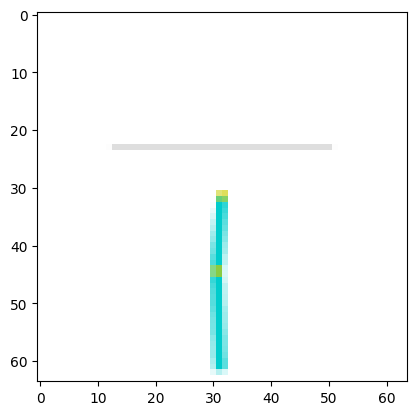

In [3]:
plt.imshow(obs[:, :, :3] / 255)

In [4]:
samples = random_sample_single_env(env, num_steps=data_steps)
for i in range(data_steps):
    buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())

In [5]:
encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)

In [6]:
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(256)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        latent = encoder(obs)
        reconstruction = decoder(latent)
        loss = torch.nn.functional.mse_loss(reconstruction, obs)
        loss.backward()
        opt.step()
        opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)

2000
4000
6000
8000
10000


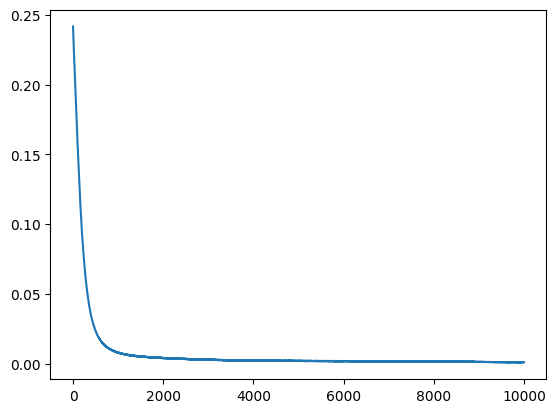

In [7]:
plt.plot(losses)


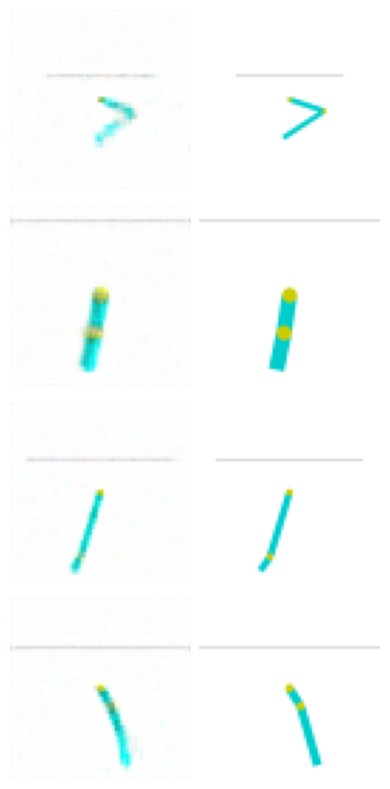

In [8]:
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()
fig.savefig("direct_dim.png")

In [9]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Latent ID: 5.515341258997229 +- 0.05908690432169737
Image ID: 9.49830566181286 +- 0.149509722774982


In [10]:
# intrinsic_dim = round(np.mean(latent_ID))
# double_autoencoder = AEVAE(encoder, decoder, latent_dim, intrinsic_dim).cuda()
# int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)

# losses = []
# for i in range(train_steps):
#     if i % 1000 == 0:
#         print(i)
#     samples = buffer.sample(256)
#     obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
#     latent = double_autoencoder.compute_latent(obs).detach()
#     int_ = double_autoencoder.compute_intrinsic(latent)
#     latent_reconstruction = double_autoencoder.reconstruct_latent(int_)
#     loss = torch.nn.functional.mse_loss(latent, latent_reconstruction)
#     loss.backward()
#     int_opt.step()
#     int_opt.zero_grad()
#     losses.append(loss.detach().cpu().numpy())
# plt.plot(losses)

2000
4000
6000
8000
10000


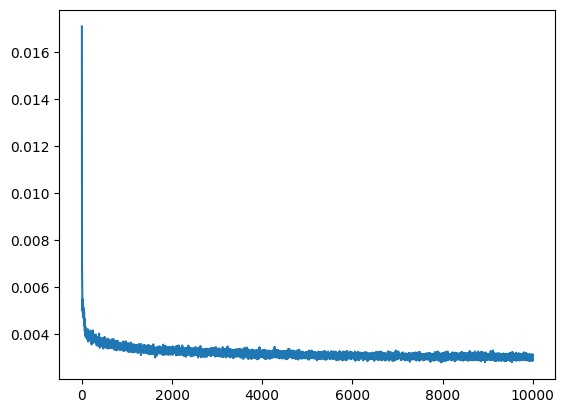

In [11]:
intrinsic_dim = round(np.mean(latent_ID))
double_autoencoder = AEVAE(encoder, decoder, latent_dim, intrinsic_dim, penalty_coef=1e-4).cuda()
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)
int_scheduler = torch.optim.lr_scheduler.ExponentialLR(int_opt, gamma=0.97)
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(256)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        loss = double_autoencoder.reconstruction_loss(obs)
        loss.backward()
        int_opt.step()
        int_opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    int_scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)
plt.plot(losses)

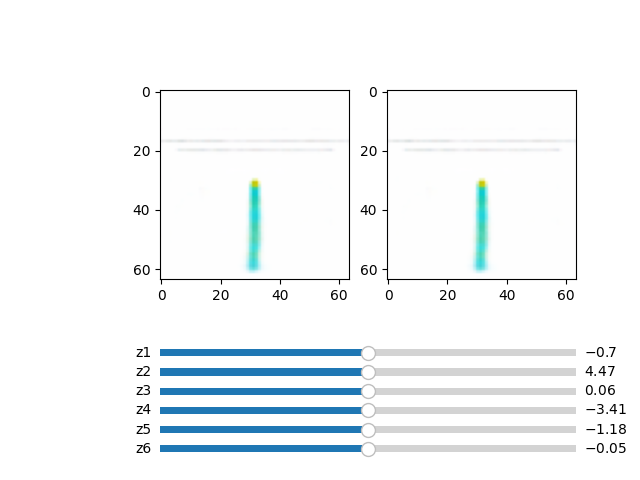

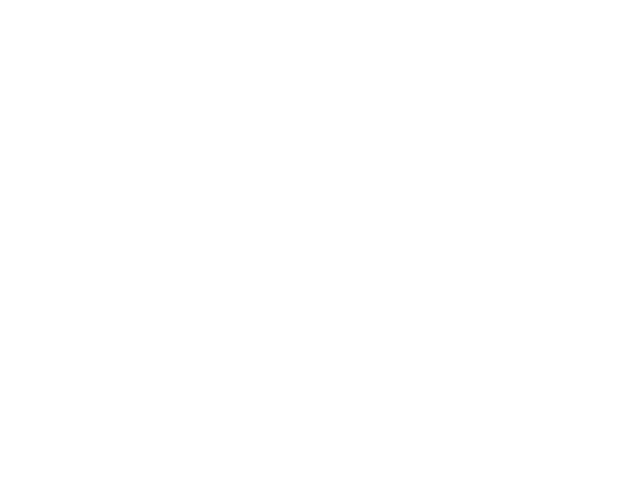

In [12]:
plt.close("all")
from matplotlib.widgets import Slider
%matplotlib widget

def decode(intrinsic):
    intrinsic_tensor = torch.tensor(intrinsic).cuda()
    reconstruction = double_autoencoder.double_decode(intrinsic_tensor)
    reconstruction = to_numpy(reconstruction[0].transpose(-3, -1))
    return reconstruction[:, :, :3], reconstruction[:, :, 3:]

intrinsic = double_autoencoder.double_encode(obs)
intrinsic = to_numpy(intrinsic[0])

plt.figure()
img = decode(intrinsic)
f, axs = plt.subplots(1, 2)
img_handle1 = axs[0].imshow(img[0])
img_handle2 = axs[1].imshow(img[1])

plt.subplots_adjust(left=0.25, bottom=0.35)

slider_axes = []
sliders = []
for i in range(intrinsic_dim):
    ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
    slider_axes.append(ax)
    slider = Slider(ax, f'z{i+1}', intrinsic[i]-20.0, intrinsic[i]+20.0, valinit=intrinsic[i])
    sliders.append(slider)

def update(val):
    for i, slider in enumerate(sliders):
        intrinsic[i] = slider.val
    img = decode(intrinsic)
    img_handle1.set_data(img[0])
    img_handle2.set_data(img[1])
    plt.draw()

for slider in sliders:
    slider.on_changed(update)

plt.show()

In [13]:
# plt.close("all")

# intrinsic = double_autoencoder.double_encode(obs)
# intrinsic_base = to_numpy(intrinsic[0].float())
# intrinsic_vecs = to_numpy(intrinsic[1:5].float()) - intrinsic_base

# f, axs = plt.subplots(1, 2)

# img = decode(intrinsic_base)
# img_handle1 = axs[0].imshow(img[0])
# img_handle2 = axs[1].imshow(img[1])

# plt.subplots_adjust(left=0.25, bottom=0.35)

# sliders = []
# for i in range(intrinsic_dim):
#     ax = f.add_axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
#     slider = Slider(ax, f'v{i+1}', -5.0, +5.0, valinit=0)
#     sliders.append(slider)

# def update(val):
#     intrinsic_cur = intrinsic_base.copy()
#     for i, s in enumerate(sliders):
#         intrinsic_cur = intrinsic_cur + s.val * intrinsic_vecs[i]

#     img = decode(intrinsic_cur.astype(np.float32))
#     img_handle1.set_data(img[0])
#     img_handle2.set_data(img[1])

#     f.canvas.draw_idle()  # redraw the correct figure

# for s in sliders:
#     s.on_changed(update)

# plt.show()


[53.075756 48.615    46.455208 43.02806  35.57278  32.352043]
[[-7.4939322e-01  2.8738568e-02  4.0907580e-01  2.4650149e-01
   6.4177640e-02  4.5316565e-01]
 [ 1.6494054e-01 -2.5649404e-03  2.6690277e-01  8.4776968e-01
  -1.2306640e-02 -4.2741787e-01]
 [-3.2132983e-01 -1.2423285e-01 -8.6290550e-01  3.6001152e-01
   6.7803346e-02  5.0018724e-02]
 [-5.2134043e-01  1.2257333e-01  3.2323520e-04 -2.4456929e-01
  -4.4624668e-01 -6.7396557e-01]
 [-1.8961997e-01 -3.1189856e-01  8.4207989e-02 -1.7561981e-01
   8.2228917e-01 -3.9073107e-01]
 [-1.4140210e-02  9.3350351e-01 -9.8605029e-02  1.6087512e-02
   3.4034818e-01 -5.0523553e-02]]


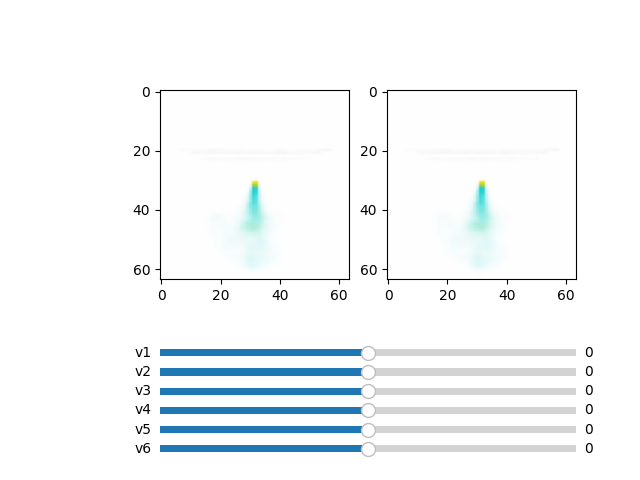

In [14]:
plt.close("all")

intrinsic = double_autoencoder.double_encode(obs)
intrinsic_base = to_numpy(intrinsic[0])
intrinsic_base = np.zeros_like(intrinsic_base) # for VAE
u, s, v = np.linalg.svd(to_numpy(intrinsic), full_matrices=False)
print(s)
print(v)
f, axs = plt.subplots(1, 2)

img = decode(intrinsic_base)
img_handle1 = axs[0].imshow(img[0])
img_handle2 = axs[1].imshow(img[1])

plt.subplots_adjust(left=0.25, bottom=0.35)

slider_axes = []
sliders = []
for i in range(intrinsic_dim):
    ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
    slider_axes.append(ax)
    slider = Slider(ax, f'v{i+1}', -10.0, +10.0, valinit=0.0)
    sliders.append(slider)

def update(val):
    intrinsic_temp = intrinsic_base.copy()
    for i, slider in enumerate(sliders):
        intrinsic_temp += slider.val * v[i]
    img = decode(intrinsic_temp)
    img_handle1.set_data(img[0])
    img_handle2.set_data(img[1])
    
    f.canvas.draw_idle()

for slider in sliders:
    slider.on_changed(update)

plt.show()